In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import seaborn as sns

In [112]:
df = pd.read_csv('../results.csv')
print(df.shape)
df.head(3)

(416160, 14)


,delta1,delta2,eps,coupling_type,x0,y0,x1,y1,x2,y2,L,s01,s02,s12
0,-0.5,-0.46,0.01,0,0.288016,-0.775659,0.410061,-0.709908,0.172427,-0.731840,1.22081,0.500918,0.461534,0.039384
1,-0.5,-0.36,0.01,0,-0.390927,0.342959,-0.159723,0.914505,0.829281,-0.038252,1.18752,0.500926,0.362788,0.138138
2,-0.5,-0.40,0.01,0,0.703515,0.819341,0.646862,-0.255873,0.956519,0.866315,1.19225,0.500917,0.402342,0.098576


In [113]:
COUPLING_NAMES = ['Inertial', 'InertialNorm', 'Dissipative', 'DissipativeNorm']
epsilons = sorted(df['eps'].unique())
print('epsilons:', epsilons)
print('coupling types:', df['coupling_type'].unique())
print('runs per point:', df.groupby(['delta1','delta2','eps','coupling_type']).size().unique())

epsilons: [np.float64(0.01), np.float64(0.05), np.float64(0.1), np.float64(0.2)]
coupling types: [0 1 2 3]
runs per point: [10]


In [ ]:
eps_val = epsilons[2]  # доступные значения: epsilons = 0.01, 0.05, 0.10, 0.20

In [ ]:
def plot_goal_maps(eps_val):
    sub = df[df['eps'] == eps_val]
    agg = sub.groupby(['delta1', 'delta2', 'coupling_type']).agg(
        L=('L', 'mean'),
        A=('A', 'mean'),
        P=('P', 'mean'),
    ).reset_index()

    fig, axes = plt.subplots(4, 3, figsize=(14, 18))
    fig.suptitle(f'Сравнение целевых функций L, A, P  —  ε = {eps_val}', fontsize=13)

    for ct in range(4):
        data = agg[agg['coupling_type'] == ct]
        for col, col_name in enumerate(['L', 'A', 'P']):
            pivot = data.pivot(index='delta1', columns='delta2', values=col_name).iloc[::-1]
            sns.heatmap(pivot, cmap='YlOrRd', ax=axes[ct, col],
                        xticklabels=10, yticklabels=10)
            axes[ct, col].set_title(f'{COUPLING_NAMES[ct]} — {col_name}', fontsize=9)
            axes[ct, col].set_xlabel('δ₂'); axes[ct, col].set_ylabel('δ₁')

    plt.tight_layout()
    plt.show()

plot_goal_maps(eps_val)

## Сравнение целевых функций

In [ ]:
import seaborn as sns

def goal_correlations(eps_val):
    sub = df[df['eps'] == eps_val]
    agg = sub.groupby(['delta1', 'delta2', 'coupling_type'])[['L', 'A', 'P']].mean().reset_index()

    mask = np.triu(np.ones((3, 3), dtype=bool))

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f'Корреляции L, A, P по точкам сетки  —  ε = {eps_val}', fontsize=12)

    for ct in range(4):
        corr = agg[agg['coupling_type'] == ct][['L', 'A', 'P']].corr()
        sns.heatmap(corr, mask=mask, annot=True, fmt='.3f',
                    vmin=-1, vmax=1, cmap='RdBu_r',
                    ax=axes[ct], square=True, linewidths=0.5,
                    cbar=(ct == 3))
        axes[ct].set_title(COUPLING_NAMES[ct])

    plt.tight_layout()
    plt.show()

goal_correlations(eps_val)

**Вывод.** A (когерентность через амплитуды) и P (через фазы) дают качественно схожую картину при диссипативной связи (ρ ≈ 0.90–0.92), но заметно расходятся при инерционной (ρ = 0.60). При инерционной связи выбор метрики влияет на результат — это нужно учитывать при постановке задачи оптимального воздействия.

L близка к A при диссипативной связи (ρ ≈ 1.00) и расходится при инерционной (ρ = 0.67) — потому что L считает только по x, A по x и y.

## Карта режимов синхронизации (доминирующий режим)

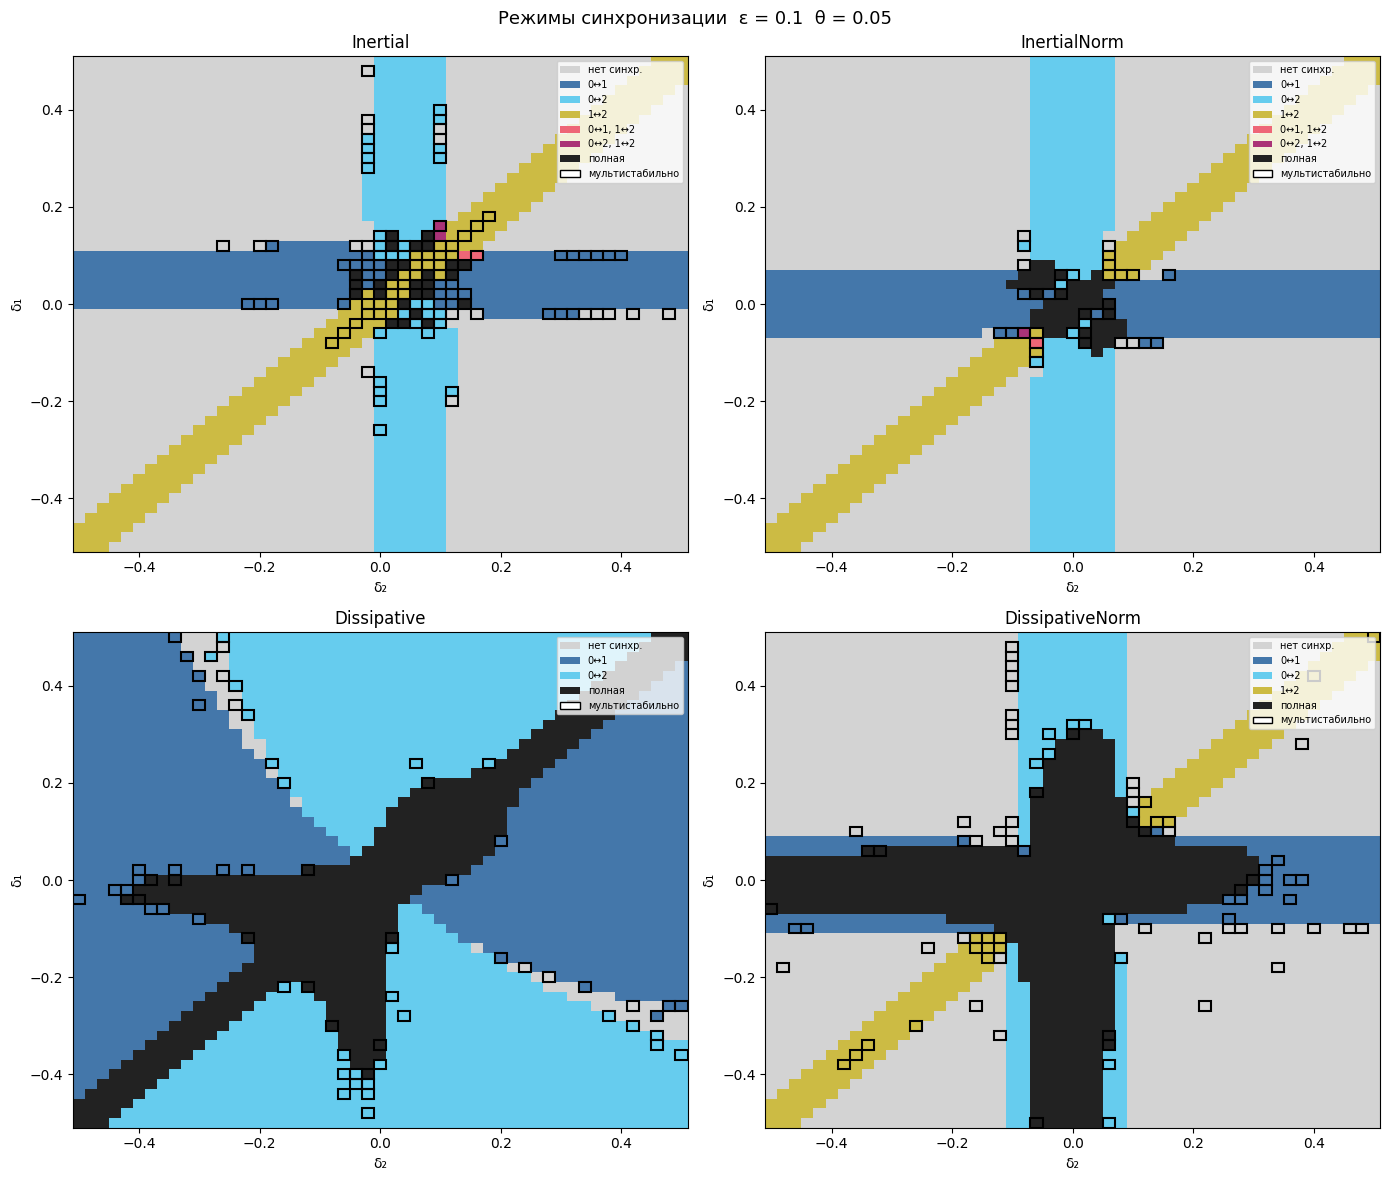

In [116]:
REGIME_LABELS = [
    'нет синхр.',    # 0
    '0↔1',           # 1
    '0↔2',           # 2
    '0↔1, 0↔2',     # 3
    '1↔2',           # 4
    '0↔1, 1↔2',     # 5
    '0↔2, 1↔2',     # 6
    'полная',        # 7
]
REGIME_COLORS = ['#d3d3d3','#4477aa','#66ccee','#228833','#ccbb44','#ee6677','#aa3377','#222222']

def sync_code(row, theta):
    return int(row['s01'] < theta) | (int(row['s02'] < theta) << 1) | (int(row['s12'] < theta) << 2)

def draw_borders(ax, pivot, linewidth=1.5, color='black'):
    from matplotlib.patches import Rectangle
    d1 = pivot.index.values
    d2 = pivot.columns.values
    s1, s2 = d1[1] - d1[0], d2[1] - d2[0]
    for i, v1 in enumerate(d1):
        for j, v2 in enumerate(d2):
            if pivot.values[i, j]:
                ax.add_patch(Rectangle(
                    (v2 - s2/2, v1 - s1/2), s2, s1,
                    fill=False, edgecolor=color, linewidth=linewidth
                ))

def plot_regime_maps(eps_val, theta=0.05):
    sub = df[df['eps'] == eps_val].copy()
    sub['code'] = sub.apply(lambda r: sync_code(r, theta), axis=1)
    
    agg = sub.groupby(['delta1', 'delta2', 'coupling_type']).agg(
        dominant_code=('code', lambda x: x.value_counts().idxmax()),
        multi_regime=('code', lambda x: x.nunique() > 1),
    ).reset_index()
    
    cmap = mcolors.ListedColormap(REGIME_COLORS)
    norm = mcolors.BoundaryNorm(np.arange(-0.5, 8.5), ncolors=8)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle(f'Режимы синхронизации  ε = {eps_val}  θ = {theta}', fontsize=13)
    
    for ct in range(4):
        ax = axes[ct // 2, ct % 2]
        data = agg[agg['coupling_type'] == ct]
        
        dom     = data.pivot(index='delta1', columns='delta2', values='dominant_code')
        mul_reg = data.pivot(index='delta1', columns='delta2', values='multi_regime')
        
        ax.pcolormesh(dom.columns, dom.index, dom.values, cmap=cmap, norm=norm, shading='auto')
        draw_borders(ax, mul_reg, linewidth=1.5, color='black')
        
        ax.set_title(COUPLING_NAMES[ct])
        ax.set_xlabel('δ₂'); ax.set_ylabel('δ₁')
        
        present = sorted(data['dominant_code'].unique())
        handles = [Patch(facecolor=REGIME_COLORS[c], label=REGIME_LABELS[c]) for c in present]
        handles.append(Patch(facecolor='white', edgecolor='black', label='мультистабильно'))
        ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=7)
    
    plt.tight_layout()
    plt.show()

plot_regime_maps(eps_val)

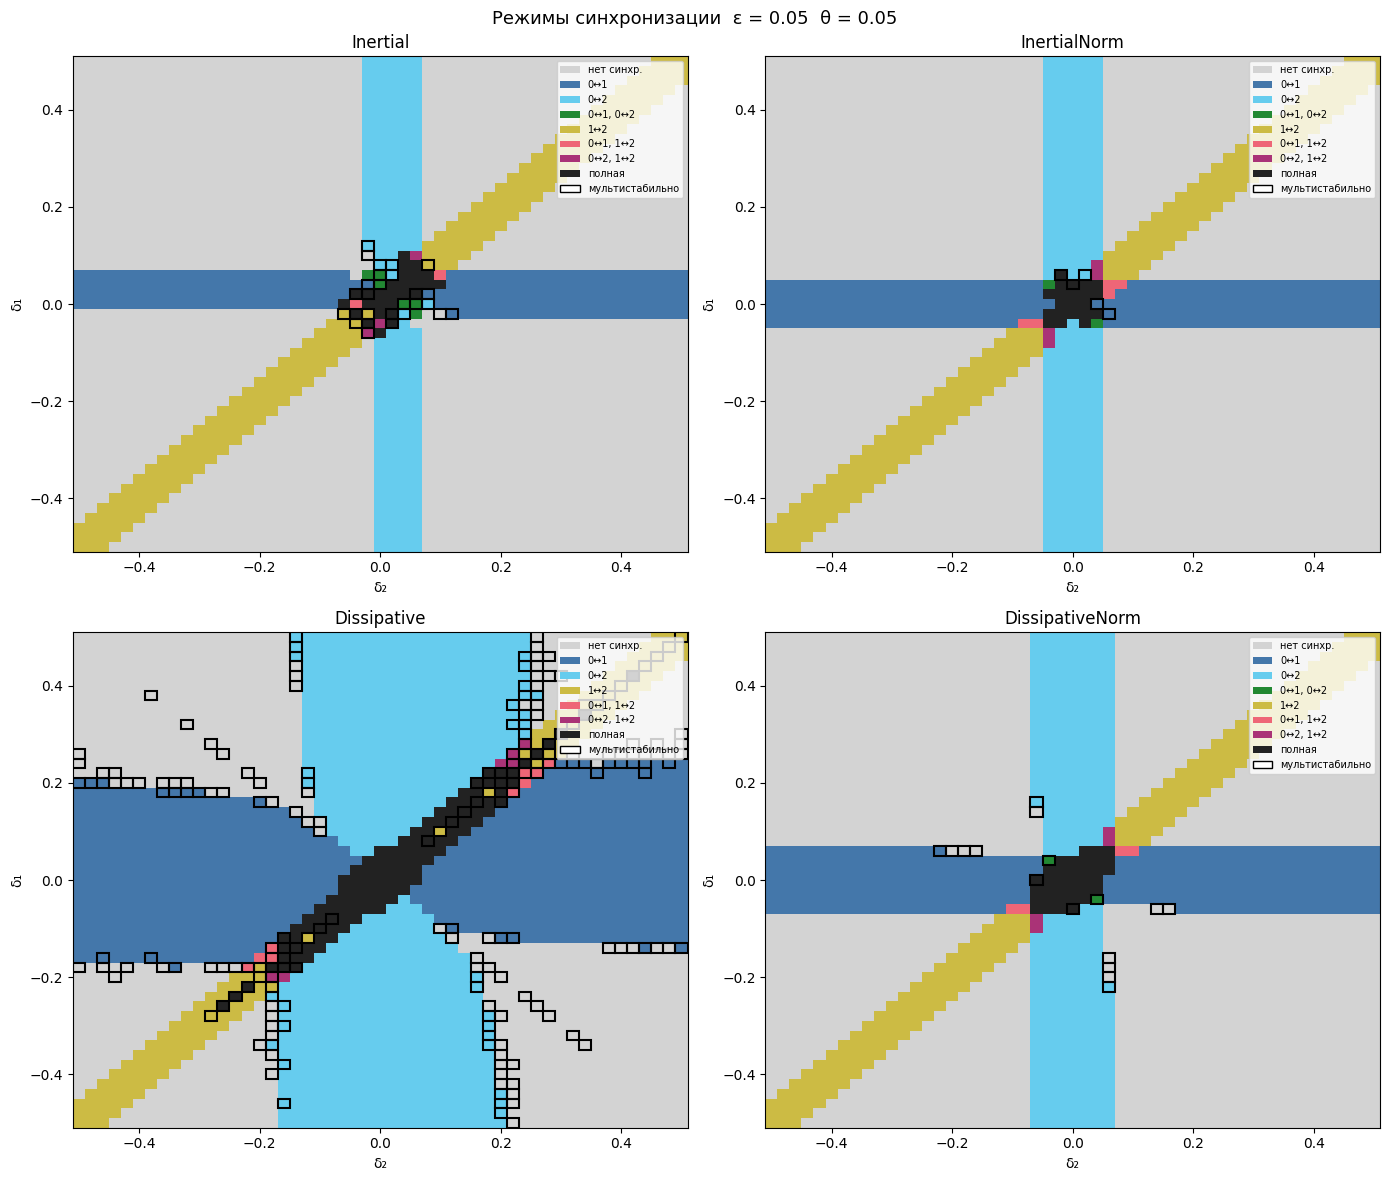

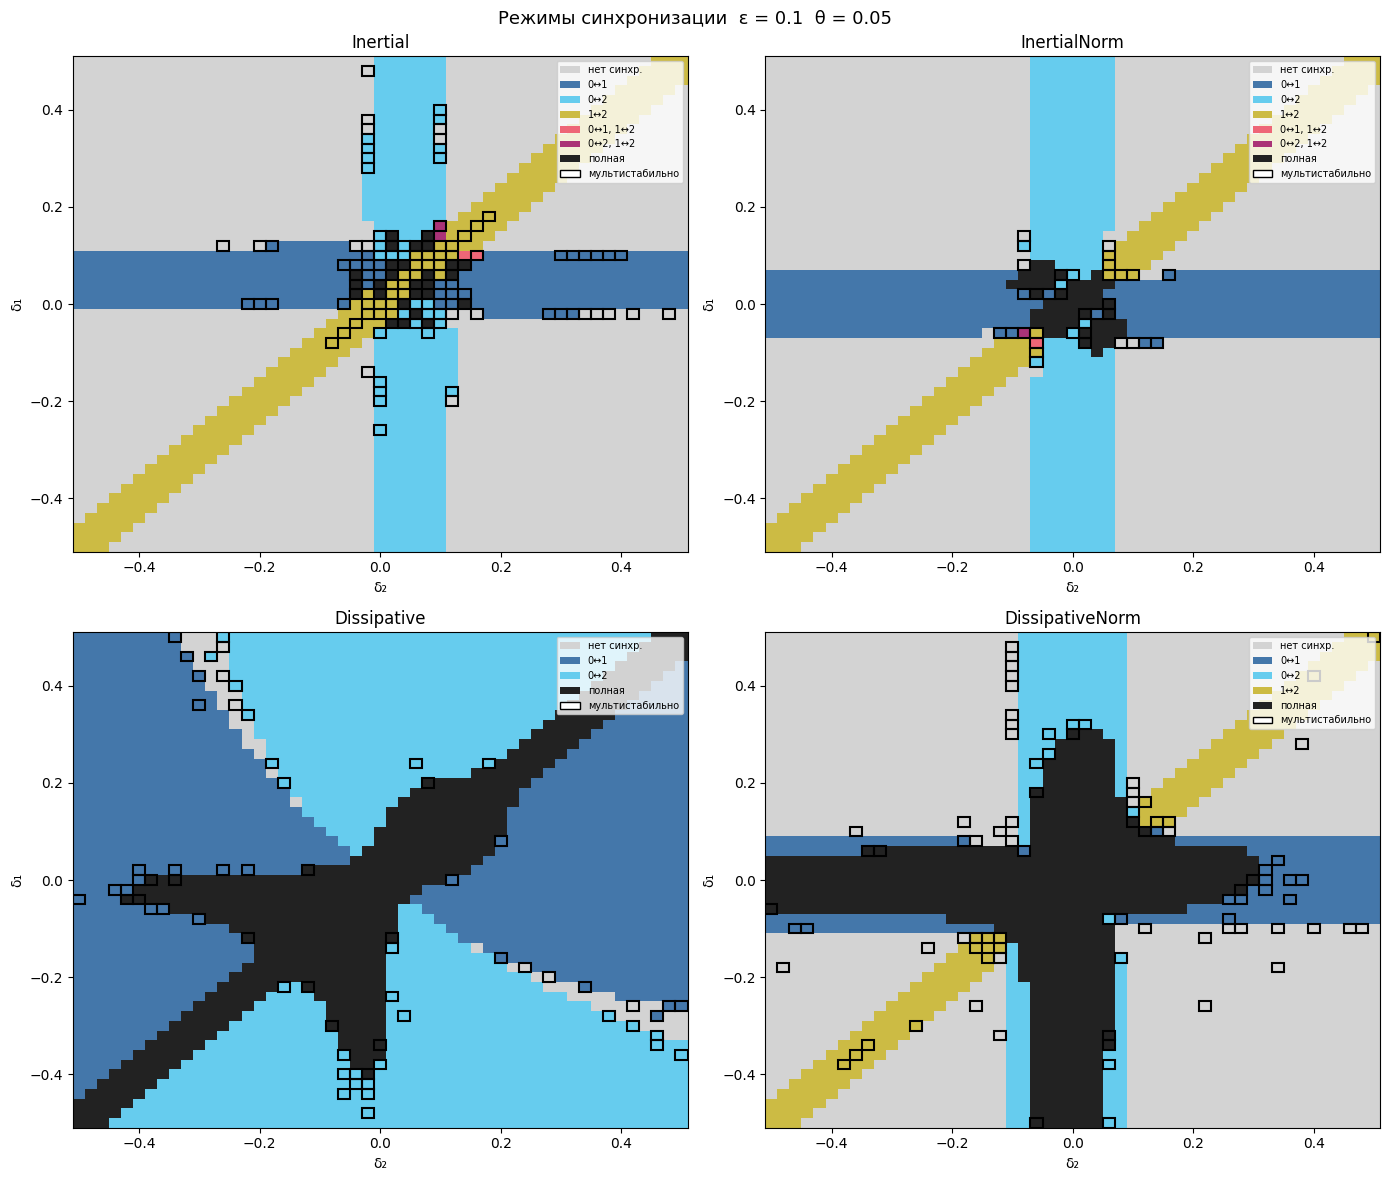

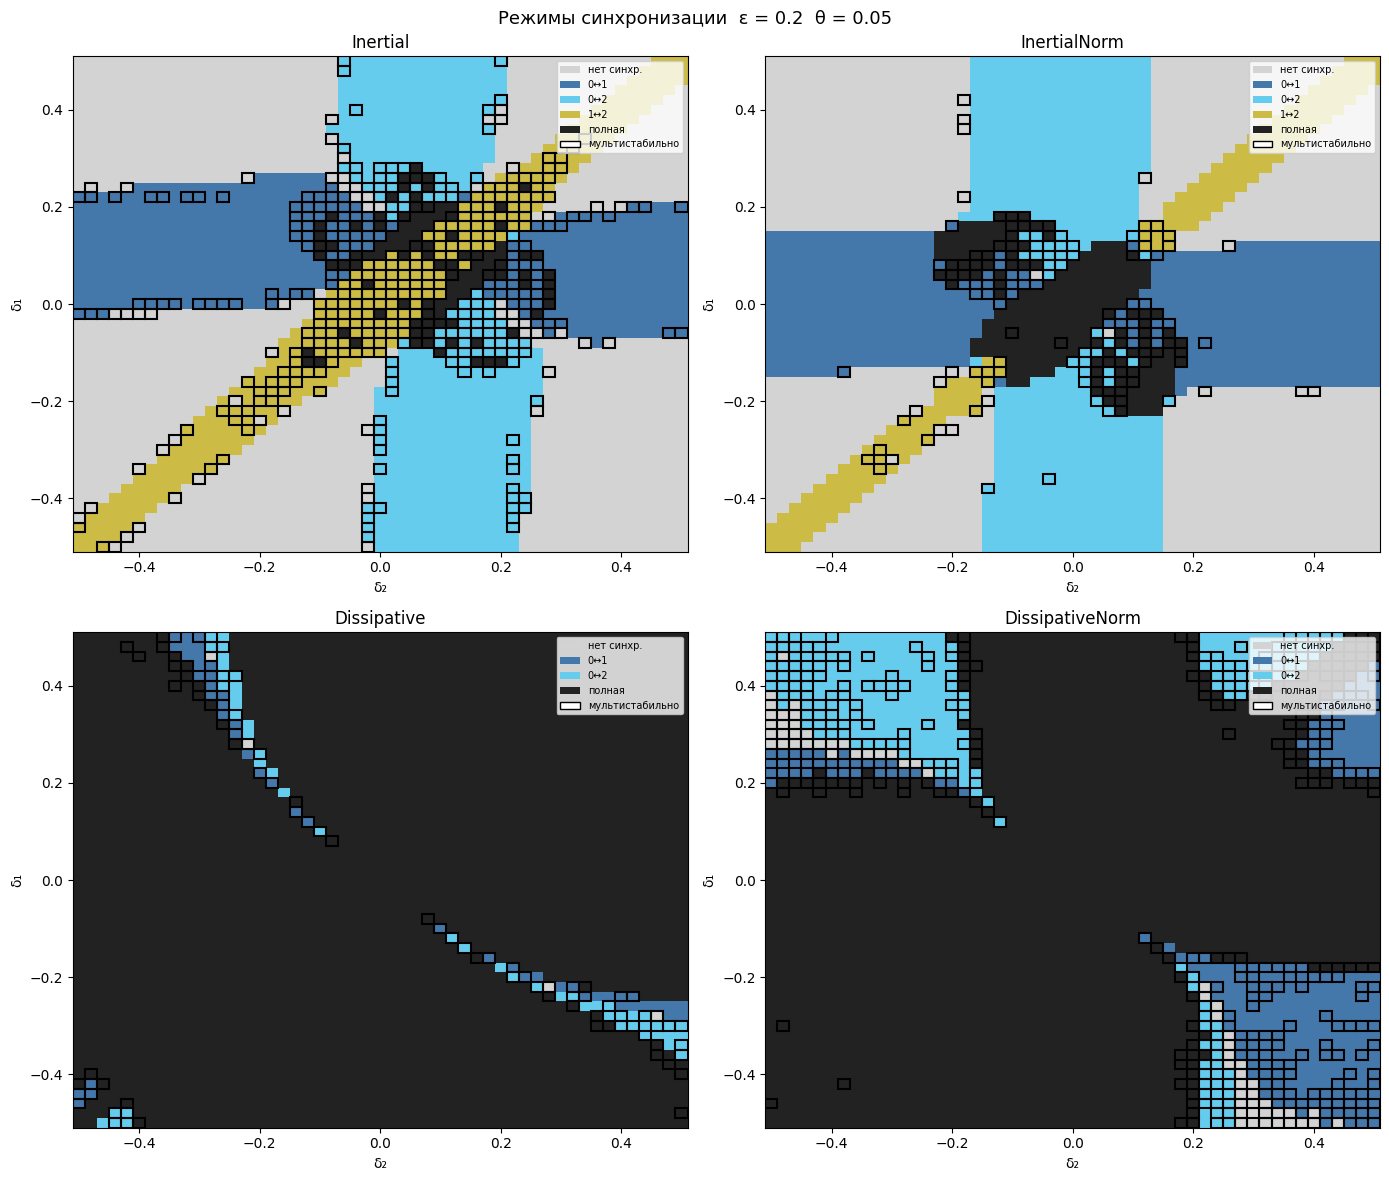

In [117]:
for eps in epsilons:
    plot_regime_maps(eps)

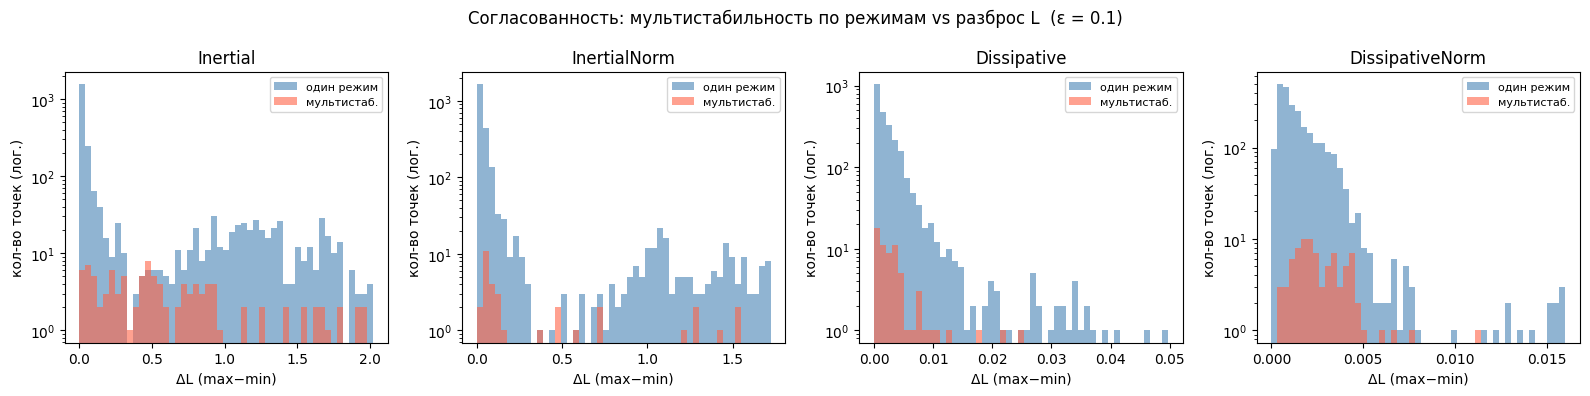

In [118]:
sub = df[df['eps'] == eps_val].copy()
sub['code'] = sub.apply(lambda r: sync_code(r, 0.05), axis=1)

agg = sub.groupby(['delta1', 'delta2', 'coupling_type']).agg(
    multi_regime=('code', lambda x: x.nunique() > 1),
    l_spread=('L', lambda x: x.max() - x.min()),
).reset_index()
agg['тип'] = agg['multi_regime'].map({True: 'мультистаб.', False: 'один режим'})

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(f'Мультистабильность по режимам vs разброс L  (ε = {eps_val})')

for ct in range(4):
    data = agg[agg['coupling_type'] == ct]
    sns.histplot(data=data, x='l_spread', hue='тип', bins=50, alpha=0.6,
                 ax=axes[ct], element='bars',
                 palette={'один режим': 'steelblue', 'мультистаб.': 'tomato'})
    axes[ct].set_yscale('log')
    axes[ct].set_title(COUPLING_NAMES[ct])
    axes[ct].set_xlabel('ΔL (max−min)')
    axes[ct].set_ylabel('кол-во точек (лог.)')

plt.tight_layout()
plt.show()

In [ ]:
def plot_regime_vs_dl(eps_val, theta=0.05):
    sub = df[df['eps'] == eps_val].copy()
    sub['code'] = sub.apply(lambda r: sync_code(r, theta), axis=1)

    agg = sub.groupby(['delta1', 'delta2', 'coupling_type']).agg(
        dominant_code=('code', lambda x: x.value_counts().idxmax()),
        l_spread=('L', lambda x: x.max() - x.min()),
        multi_regime=('code', lambda x: x.nunique() > 1),
    ).reset_index()

    cmap_reg = mcolors.ListedColormap(REGIME_COLORS)
    norm_reg = mcolors.BoundaryNorm(np.arange(-0.5, 8.5), ncolors=8)

    fig, axes = plt.subplots(4, 2, figsize=(12, 18))
    fig.suptitle(f'Режимы синхронизации и разброс ΔL  —  ε = {eps_val}', fontsize=13)

    for ct in range(4):
        data = agg[agg['coupling_type'] == ct]
        dom     = data.pivot(index='delta1', columns='delta2', values='dominant_code')
        spread  = data.pivot(index='delta1', columns='delta2', values='l_spread')
        mul_reg = data.pivot(index='delta1', columns='delta2', values='multi_regime')

        ax_reg, ax_dl = axes[ct, 0], axes[ct, 1]

        ax_reg.pcolormesh(dom.columns, dom.index, dom.values,
                          cmap=cmap_reg, norm=norm_reg, shading='auto')
        draw_borders(ax_reg, mul_reg)
        ax_reg.set_title(f'{COUPLING_NAMES[ct]} — режим')
        ax_reg.set_xlabel('δ₂'); ax_reg.set_ylabel('δ₁')
        present = sorted(data['dominant_code'].unique())
        handles = [Patch(facecolor=REGIME_COLORS[c], label=REGIME_LABELS[c]) for c in present]
        handles.append(Patch(facecolor='white', edgecolor='black', label='мультистаб.'))
        ax_reg.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=7)

        sns.heatmap(spread.iloc[::-1], cmap='Blues', ax=ax_dl,
                    xticklabels=10, yticklabels=10)
        ax_dl.set_title(f'{COUPLING_NAMES[ct]} — ΔL (max−min)')
        ax_dl.set_xlabel('δ₂'); ax_dl.set_ylabel('δ₁')

    plt.tight_layout()
    plt.show()

plot_regime_vs_dl(eps_val)

## Исследование $\Delta L$ как критерия мультистабильности

**1. Постановка вопроса.**
Проверялась гипотеза: можно ли использовать разброс когерентности
$\Delta L = L_{\max} - L_{\min}$ по $n_{\text{ic}}$ начальным условиям
как индикатор мультистабильности — альтернативу критерию по разнообразию sync\_code.

**2. Построение гистограммы.**
Для $\varepsilon = 0.1$, типа связи Inertial, по всем точкам сетки $(\delta_1, \delta_2)$
вычислялись $\Delta L$ и флаг мультистабильности (истина, если по 10 НУ встречается $> 1$ значения sync\_code).
Построена гистограмма $\Delta L$ раздельно для моно- и мультирежимных точек (лог. шкала).
Распределения не разделились — гипотеза отвергнута.

Для подтверждения выбраны два контрпримера.

---

**Точка A: мультистабильна, но $\Delta L \approx 0$**
$\delta_1 = -0.20$, $\delta_2 = 0.12$, Inertial, $\varepsilon = 0.1$; $\omega = [1.00,\ 0.80,\ 1.12]$.

- *Данные:* 10 прогонов дали коды $[2, 0, 0, 0, 2, 0, 0, 2, 0, 2]$, $L \in [0.833, 0.842]$, $\Delta L \approx 0.009$.
- *НУ:* никакой кластеризации начальных условий по режиму нет — режим определяется тонкими особенностями траектории, а не начальным положением.
- *Симуляция (C++):* временны́е ряды для НУ с кодом=2 и кодом=0 визуально различимы по фазе, но амплитуды одинаковы.
- *Объяснение:* $x_1$ колеблется на частоте $\omega_1 = 0.80$, далёкой от остальных, поэтому $\langle x_1 x_0 \rangle \approx \langle x_1 x_2 \rangle \approx 0$ в обоих режимах. Единственный изменяющийся член $\langle x_0 x_2 \rangle$ мал на фоне суммы $\sum_i \langle x_i^2 \rangle$, откуда $\Delta L \ll L$.

---

**Точка Б: один режим, но $\Delta L \approx 1.88$**
$\delta_1 = -0.50$, $\delta_2 = -0.50$, Inertial, $\varepsilon = 0.1$; $\omega = [1.00,\ 0.50,\ 0.50]$.

- *Данные:* все 10 прогонов — код=4 (синхронизация $x_1 \leftrightarrow x_2$), $L \in [0.235, 2.111]$, $\Delta L \approx 1.876$.
- *НУ:* значения $L$ чётко делятся на два кластера — $L \approx 2.1$ (7 прогонов) и $L \approx 0.235$ (3 прогона) — при одном и том же режиме синхронизации.
- *Симуляция (C++):* в обоих случаях $x_1$ и $x_2$ синхронны, но амплитуды колебаний кардинально отличаются.
- *Объяснение:* оба листа расстроены на $-0.50$ относительно хаба. Система имеет два аттрактора с разными амплитудами, но одинаковой топологией синхронизации — sync\_code их не различает, а $L$ различает.

---

**Итог:** $\Delta L$ и sync\_code измеряют несвязанные свойства системы.
Точка А показывает, что мультистабильность по режиму не влечёт разброс $L$.
Точка Б показывает, что разброс $L$ не влечёт мультистабильность по режиму.

### Поиск контрпримеров

In [ ]:
## Верификация методологии

theta = 0.05
sub = df[df['eps'] == eps_val].copy()
sub['code'] = sub.apply(lambda r: sync_code(r, theta), axis=1)

agg = sub.groupby(['delta1', 'delta2', 'coupling_type']).agg(
    multi_regime=('code', lambda x: x.nunique() > 1),
    l_spread=('L', lambda x: x.max() - x.min()),
    codes=('code', list),
    L_vals=('L', list),
).reset_index()

ct = 0  # Inertial
data = agg[agg['coupling_type'] == ct]

# 1. Пример точки с мультистабильностью и малым l_spread
multi_small = data[data['multi_regime'] & (data['l_spread'] < 0.1)].head(3)
print("=== Мультистабильные точки с малым ΔL (<0.1) ===")
for _, row in multi_small.iterrows():
    print(f"  δ1={row.delta1:.2f} δ2={row.delta2:.2f}  ΔL={row.l_spread:.4f}")
    print(f"  коды по 10 НУ: {row.codes}")
    print(f"  L по 10 НУ:    {[round(x,3) for x in row.L_vals]}")

print()

# 2. Пример точки с одним режимом и большим l_spread
mono_large = data[~data['multi_regime'] & (data['l_spread'] > 0.5)].head(3)
print("=== Одно-режимные точки с большим ΔL (>0.5) ===")
for _, row in mono_large.iterrows():
    print(f"  δ1={row.delta1:.2f} δ2={row.delta2:.2f}  ΔL={row.l_spread:.4f}")
    print(f"  коды по 10 НУ: {row.codes}")
    print(f"  L по 10 НУ:    {[round(x,3) for x in row.L_vals]}")

print()

=== Мультистабильные точки с малым ΔL (<0.1) ===
  δ1=-0.20 δ2=0.12  ΔL=0.0088
  коды по 10 НУ: [2, 0, 0, 0, 2, 0, 0, 2, 0, 2]
  L по 10 НУ:    [0.834, 0.838, 0.834, 0.833, 0.836, 0.839, 0.835, 0.837, 0.833, 0.842]
  δ1=-0.18 δ2=0.12  ΔL=0.0177
  коды по 10 НУ: [2, 2, 0, 2, 2, 2, 0, 2, 2, 2]
  L по 10 НУ:    [0.838, 0.834, 0.852, 0.842, 0.835, 0.851, 0.844, 0.835, 0.835, 0.836]
  δ1=-0.04 δ2=0.06  ΔL=0.0997
  коды по 10 НУ: [2, 7, 2, 7, 2, 2, 2, 2, 2, 2]
  L по 10 НУ:    [0.702, 0.798, 0.702, 0.783, 0.702, 0.7, 0.705, 0.698, 0.704, 0.702]

=== Одно-режимные точки с большим ΔL (>0.5) ===
  δ1=-0.50 δ2=-0.50  ΔL=1.8762
  коды по 10 НУ: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
  L по 10 НУ:    [2.101, 2.1, 2.111, 0.235, 1.977, 2.11, 2.094, 0.236, 0.235, 2.109]
  δ1=-0.50 δ2=0.00  ΔL=0.9441
  коды по 10 НУ: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
  L по 10 НУ:    [1.523, 1.513, 0.582, 1.515, 0.585, 0.582, 1.523, 1.526, 1.517, 1.515]
  δ1=-0.50 δ2=0.02  ΔL=1.1586
  коды по 10 НУ: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2

### Проверка точки с маленьким $\Delta L$, но мультистабильностью

In [120]:
# Проверка гипотезы: осциллятор 1 доминирует в сумме
# Берём точку δ1=-0.20, δ2=0.12, смотрим начальные условия по режимам

point = df[
    (df['eps'] == epsilons[2]) &
    (df['coupling_type'] == 0) &
    (np.isclose(df['delta1'], -0.20, atol=0.01)) &
    (np.isclose(df['delta2'],  0.12, atol=0.01))
].copy()
point['code'] = point.apply(lambda r: sync_code(r, 0.05), axis=1)

print("δ1=-0.20, δ2=0.12, Inertial — все 10 прогонов:")
print(f"{'код':>5}  {'L':>6}  {'x0':>7}  {'y0':>7}  {'x1':>7}  {'y1':>7}  {'x2':>7}  {'y2':>7}")
for _, r in point.iterrows():
    print(f"{int(r.code):>5}  {r.L:>6.3f}  {r.x0:>7.3f}  {r.y0:>7.3f}  {r.x1:>7.3f}  {r.y1:>7.3f}  {r.x2:>7.3f}  {r.y2:>7.3f}")

δ1=-0.20, δ2=0.12, Inertial — все 10 прогонов:
  код       L       x0       y0       x1       y1       x2       y2
    2   0.834   -0.493   -0.613    0.172   -0.363    0.988    0.593
    0   0.838    0.512    0.714   -0.237    0.548   -0.352   -0.166
    0   0.834    0.795   -0.126   -0.405   -0.115   -0.720   -0.839
    0   0.833   -0.390   -0.163    0.483    0.556   -0.589    0.154
    2   0.836   -0.309    0.341    0.134    0.199    0.150   -0.572
    0   0.839   -0.591   -0.422    0.486    0.227    0.924   -0.645
    0   0.835    0.618    0.091   -0.694   -0.581   -0.089   -0.421
    2   0.837   -0.324   -0.207    0.684   -0.761    0.649   -0.812
    0   0.833   -0.101    0.173    0.551    0.618    0.744    0.933
    2   0.842   -0.967    0.594   -0.337   -0.912   -0.121   -0.540


### Проверка точки с высоким $\Delta L$, но однорежимностью

In [121]:
# δ1=-0.50, δ2=-0.50: один режим (код=4), но огромный разброс L
point2 = df[
    (df['eps'] == epsilons[2]) &
    (df['coupling_type'] == 0) &
    (np.isclose(df['delta1'], -0.50, atol=0.01)) &
    (np.isclose(df['delta2'], -0.50, atol=0.01))
].copy()
point2['code'] = point2.apply(lambda r: sync_code(r, 0.05), axis=1)

print("δ1=-0.50, δ2=-0.50, Inertial — все 10 прогонов:")
print(f"{'код':>5}  {'L':>6}  {'x0':>7}  {'y0':>7}  {'x1':>7}  {'y1':>7}  {'x2':>7}  {'y2':>7}")
for _, r in point2.iterrows():
    print(f"{int(r.code):>5}  {r.L:>6.3f}  {r.x0:>7.3f}  {r.y0:>7.3f}  {r.x1:>7.3f}  {r.y1:>7.3f}  {r.x2:>7.3f}  {r.y2:>7.3f}")

δ1=-0.50, δ2=-0.50, Inertial — все 10 прогонов:
  код       L       x0       y0       x1       y1       x2       y2
    4   2.101   -0.731    0.124   -0.921   -0.503    0.021   -0.818
    4   2.100    0.426    0.041   -0.723   -0.480   -0.761   -0.038
    4   2.111   -0.575   -0.624    0.422    0.895   -0.043    0.626
    4   0.235   -0.611    0.302   -1.000   -0.378    0.667    0.211
    4   1.977   -0.236   -0.839    0.810    0.894    0.740    0.176
    4   2.110    0.755   -0.380   -0.068   -0.208   -0.248   -0.690
    4   2.094   -0.609    0.406   -0.304    0.477    0.885    0.545
    4   0.236    0.879   -0.325    0.368   -0.558    0.896    0.222
    4   0.235   -0.788    0.644   -0.251   -0.461   -0.066    0.480
    4   2.109    0.511   -0.162    0.485    0.905    0.156    0.105


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

t_trans = 600.0
plot_window = 40.0

runs = [
    {
        'title': 'δ₁=-0.20, δ₂=0.12 — код=2 (0↔2 синхр.), L≈0.834',
        'path': '../simulation/demo/small_l_code2.csv',
        'labels': ['x₀ (hub, ω=1.00)', 'x₁ (ω=0.80)', 'x₂ (ω=1.12)'],
    },
    {
        'title': 'δ₁=-0.20, δ₂=0.12 — код=0 (нет синхр.), L≈0.838',
        'path': '../simulation/demo/small_l_code0.csv',
        'labels': ['x₀ (hub, ω=1.00)', 'x₁ (ω=0.80)', 'x₂ (ω=1.12)'],
    },
    {
        'title': 'δ₁=-0.50, δ₂=-0.50 — код=4 (1↔2 синхр.), L≈2.1',
        'path': '../simulation/demo/large_dl_high_l.csv',
        'labels': ['x₀ (hub, ω=1.00)', 'x₁ (ω=0.50)', 'x₂ (ω=0.50)'],
    },
    {
        'title': 'δ₁=-0.50, δ₂=-0.50 — код=4 (1↔2 синхр.), L≈0.235',
        'path': '../simulation/demo/large_dl_low_l.csv',
        'labels': ['x₀ (hub, ω=1.00)', 'x₁ (ω=0.50)', 'x₂ (ω=0.50)'],
    },
]

colors = ['#e41a1c', '#4daf4a', '#377eb8']

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
fig.suptitle('C++ vdp_sim — осцилляции в установившемся режиме', fontsize=13)

for ax, run in zip(axes, runs):
    df_run = pd.read_csv(run['path'])
    steady = df_run[(df_run['t'] >= t_trans) & (df_run['t'] < t_trans + plot_window)]

    for col, c, lbl in zip(['x0', 'x1', 'x2'], colors, run['labels']):
        ax.plot(steady['t'], steady[col], color=c, lw=0.9, label=lbl)

    rms = [np.sqrt((steady[f'x{i}']**2).mean()) for i in range(3)]
    ax.set_title(f"{run['title']}  |  RMS: x₀={rms[0]:.3f}, x₁={rms[1]:.3f}, x₂={rms[2]:.3f}",
                 fontsize=9)
    ax.set_ylabel('x')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('t')
plt.tight_layout()
plt.show()